# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech

- Nama: Reyhan Ezra Bimantara
- Email: pro.bimantara@gmail.com
- Id Dicoding: rrexzra

## Persiapan

| No | Kolom                     | Deskripsi                                                                 |
|----|---------------------------|---------------------------------------------------------------------------|
| 1  | EmployeeId                | Employee Identifier                                                       |
| 2  | Attrition                 | Did the employee attrition? (0=no, 1=yes)                                 |
| 3  | Age                       | Age of the employee                                                       |
| 4  | BusinessTravel           | Travel commitments for the job                                           |
| 5  | DailyRate                 | Daily salary                                                              |
| 6  | Department                | Employee Department                                                       |
| 7  | DistanceFromHome         | Distance from work to home (in km)                                       |
| 8  | Education                 | 1-Below College, 2-College, 3-Bachelor, 4-Master, 5-Doctor                |
| 9  | EducationField            | Field of Education                                                        |
| 10 | EnvironmentSatisfaction   | 1-Low, 2-Medium, 3-High, 4-Very High                                     |
| 11 | Gender                    | Employee's gender                                                         |
| 12 | HourlyRate                | Hourly salary                                                             |
| 13 | JobInvolvement            | 1-Low, 2-Medium, 3-High, 4-Very High                                     |
| 14 | JobLevel                  | Level of job (1 to 5)                                                     |
| 15 | JobRole                   | Job Roles                                                                 |
| 16 | JobSatisfaction           | 1-Low, 2-Medium, 3-High, 4-Very High                                     |
| 17 | MaritalStatus             | Marital Status                                                            |
| 18 | MonthlyIncome             | Monthly salary                                                            |
| 19 | MonthlyRate               | Monthly rate                                                              |
| 20 | NumCompaniesWorked        | Number of companies worked at                                            |
| 21 | Over18                    | Over 18 years of age?                                                     |
| 22 | OverTime                  | Overtime?                                                                 |
| 23 | PercentSalaryHike         | The percentage increase in salary last year                              |
| 24 | PerformanceRating         | 1-Low, 2-Good, 3-Excellent, 4-Outstanding                                |
| 25 | RelationshipSatisfaction  | 1-Low, 2-Medium, 3-High, 4-Very High                                     |
| 26 | StandardHours             | Standard Hours                                                            |
| 27 | StockOptionLevel          | Stock Option Level                                                        |
| 28 | TotalWorkingYears         | Total years worked                                                        |
| 29 | TrainingTimesLastYear     | Number of training attended last year                                    |
| 30 | WorkLifeBalance           | 1-Low, 2-Good, 3-Excellent, 4-Outstanding                                |
| 31 | YearsAtCompany            | Years at Company                                                          |
| 32 | YearsInCurrentRole        | Years in the current role                                                 |
| 33 | YearsSinceLastPromotion   | Years since the last promotion                                            |
| 34 | YearsWithCurrManager      | Years with the current manager                                            |


### Menyiapkan library yang dibutuhkan

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import preprocessing, model_selection, svm
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, precision_score,
    recall_score, roc_curve, roc_auc_score,
    classification_report, f1_score
)

import joblib

### Menyiapkan data yang akan diguankan

## Data Understanding

### Connect to Dataset

In [6]:
url = 'https://raw.githubusercontent.com/dicodingacademy/dicoding_dataset/main/employee/employee_data.csv'
employee_df = pd.read_csv(url)
employee_df.head()

,EmployeeId,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,1,38,NaN,Travel_Frequently,1444,Human Resources,1,4,Other,1,...,2,80,1,7,2,3,6,2,1,2
1,2,37,1.0,Travel_Rarely,1141,Research & Development,11,2,Medical,1,...,1,80,0,15,2,1,1,0,0,0
2,3,51,1.0,Travel_Rarely,1323,Research & Development,4,4,Life Sciences,1,...,3,80,3,18,2,4,10,0,2,7
3,4,42,0.0,Travel_Frequently,555,Sales,26,3,Marketing,1,...,4,80,1,23,2,4,20,4,4,8
4,5,40,NaN,Travel_Rarely,1194,Research & Development,2,4,Medical,1,...,2,80,3,20,2,3,5,3,0,2


### Dataset Dimension

In [7]:
employee_df.shape

(1470, 35)

### Dataset Summary

In [8]:
employee_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   EmployeeId                1470 non-null   int64  
 1   Age                       1470 non-null   int64  
 2   Attrition                 1058 non-null   float64
 3   BusinessTravel            1470 non-null   object 
 4   DailyRate                 1470 non-null   int64  
 5   Department                1470 non-null   object 
 6   DistanceFromHome          1470 non-null   int64  
 7   Education                 1470 non-null   int64  
 8   EducationField            1470 non-null   object 
 9   EmployeeCount             1470 non-null   int64  
 10  EnvironmentSatisfaction   1470 non-null   int64  
 11  Gender                    1470 non-null   object 
 12  HourlyRate                1470 non-null   int64  
 13  JobInvolvement            1470 non-null   int64  
 14  JobLevel

### Handling Missing Values

In [9]:
#Pengecekan untuk nilai null
print(f'Jumlah Null Values : \n{(employee_df.isnull() | employee_df.isna() | employee_df.empty).sum()}')

Jumlah Null Values : 
EmployeeId                    0
Age                           0
Attrition                   412
BusinessTravel                0
DailyRate                     0
Department                    0
DistanceFromHome              0
Education                     0
EducationField                0
EmployeeCount                 0
EnvironmentSatisfaction       0
Gender                        0
HourlyRate                    0
JobInvolvement                0
JobLevel                      0
JobRole                       0
JobSatisfaction               0
MaritalStatus                 0
MonthlyIncome                 0
MonthlyRate                   0
NumCompaniesWorked            0
Over18                        0
OverTime                      0
PercentSalaryHike             0
PerformanceRating             0
RelationshipSatisfaction      0
StandardHours                 0
StockOptionLevel              0
TotalWorkingYears             0
TrainingTimesLastYear         0
WorkLifeBalance   

Terdapat **412 baris data yang memiliki value null** pada kolom `Attrition`

In [10]:
employee_df = employee_df.dropna()

### Handling Duplicated Values

###Checking Object Column

In [11]:
employee_df.select_dtypes(include=['object']).dtypes

,0
BusinessTravel,object
Department,object
EducationField,object
Gender,object
JobRole,object
MaritalStatus,object
Over18,object
OverTime,object


### Checking Integer Columns

In [12]:
employee_df.select_dtypes(include=['int64']).dtypes

,0
EmployeeId,int64
Age,int64
DailyRate,int64
DistanceFromHome,int64
Education,int64
EmployeeCount,int64
EnvironmentSatisfaction,int64
HourlyRate,int64
JobInvolvement,int64
JobLevel,int64


### Checking Float Columns

In [13]:
employee_df.select_dtypes(include=['float64']).dtypes

,0
Attrition,float64


In [14]:
employee_df['Attrition'] = employee_df['Attrition'].astype(int)

<ipython-input-14-5bec8de52914>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  employee_df['Attrition'] = employee_df['Attrition'].astype(int)


In [15]:
# remove the duplicates data
employee_df.drop_duplicates(inplace=True)
if employee_df.duplicated().sum() == 0:
  print('Sudah tidak ada data yang terduplikat!')

Sudah tidak ada data yang terduplikat!


<ipython-input-15-77add530c67a>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  employee_df.drop_duplicates(inplace=True)


### Dataset Descriptive Statistics

In [16]:
employee_df.describe()

,EmployeeId,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeCount,EnvironmentSatisfaction,HourlyRate,JobInvolvement,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1058.000000,1058.000000,1058.000000,1058.000000,1058.000000,1058.000000,1058.0,1058.000000,1058.000000,1058.00000,...,1058.000000,1058.0,1058.000000,1058.000000,1058.000000,1058.000000,1058.000000,1058.00000,1058.000000,1058.000000
mean,736.656900,37.055766,0.169187,809.542533,8.978261,2.879017,1.0,2.712665,65.643667,2.73724,...,2.726843,80.0,0.762760,11.435728,2.769376,2.763705,7.065217,4.26087,2.203214,4.142722
std,427.440538,9.410421,0.375094,408.478049,8.040608,1.031442,0.0,1.092959,20.324861,0.70473,...,1.090970,0.0,0.837537,8.016429,1.302689,0.707392,6.265227,3.61747,3.266948,3.599044
min,2.000000,18.000000,0.000000,102.000000,1.000000,1.000000,1.0,1.000000,30.000000,1.00000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.00000,0.000000,0.000000
25%,364.250000,30.000000,0.000000,465.250000,2.000000,2.000000,1.0,2.000000,48.000000,2.00000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.00000,0.000000,2.000000
50%,731.500000,36.000000,0.000000,817.500000,7.000000,3.000000,1.0,3.000000,65.000000,3.00000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.00000,1.000000,3.000000
75%,1117.750000,43.000000,0.000000,1168.500000,13.000000,4.000000,1.0,4.000000,83.000000,3.00000,...,4.000000,80.0,1.000000,16.000000,3.000000,3.000000,9.000000,7.00000,3.000000,7.000000
max,1470.000000,60.000000,1.000000,1499.000000,29.000000,5.000000,1.0,4.000000,100.000000,4.00000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.00000,15.000000,17.000000


In [17]:
employee_df.describe(include='object')

,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,Over18,OverTime
count,1058,1058,1058,1058,1058,1058,1058,1058
unique,3,3,6,2,9,3,1,2
top,Travel_Rarely,Research & Development,Life Sciences,Male,Sales Executive,Married,Y,No
freq,746,701,436,620,232,464,1058,751


### Exporting Clean Dataset

In [18]:
clean_employee_df = employee_df
clean_employee_df.to_csv('clean_employee_data.csv', index=False)

## Exploratory Data Analysis

### Attrition Distribution

In [19]:
from math import e
employee_df['Attrition'] = employee_df['Attrition'].factorize(['No', 'Yes'])[0]
employee_df['Attrition'].value_counts()

,count
Attrition,
0,879
1,179


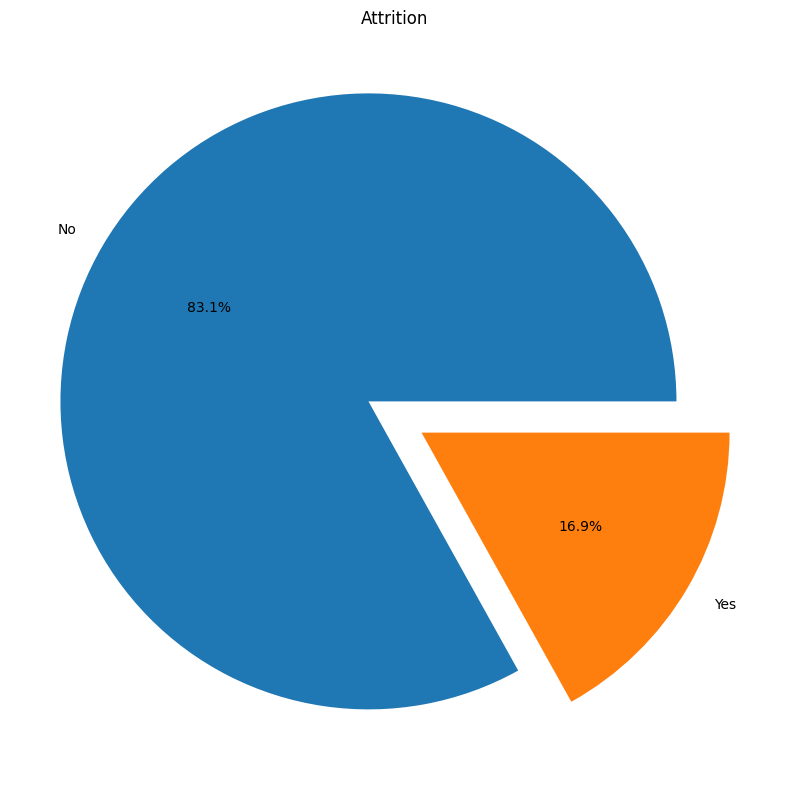

In [20]:
plt.figure(figsize=(10, 10))
pie = employee_df.groupby('Attrition')['Attrition'].count()
plt.pie(pie, explode=[0.1, 0.1], labels=['No', 'Yes'], autopct='%1.1f%%')
plt.title('Attrition')
plt.show()

### Business Travel by Attrition

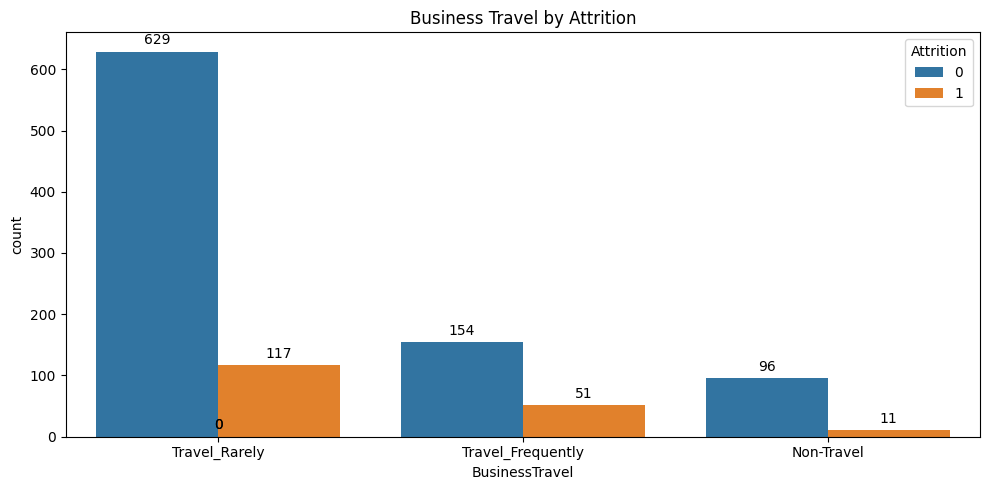

In [21]:
plt.figure(figsize=(10, 5))
ax = sns.countplot(x='BusinessTravel', hue='Attrition', data=employee_df)
plt.title('Business Travel by Attrition')

# Menambahkan angka di atas setiap batang
for p in ax.patches:
    height = p.get_height()
    ax.annotate(str(int(p.get_height())), (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 8), textcoords='offset points')

plt.tight_layout()
plt.show()

### Age by Attrition

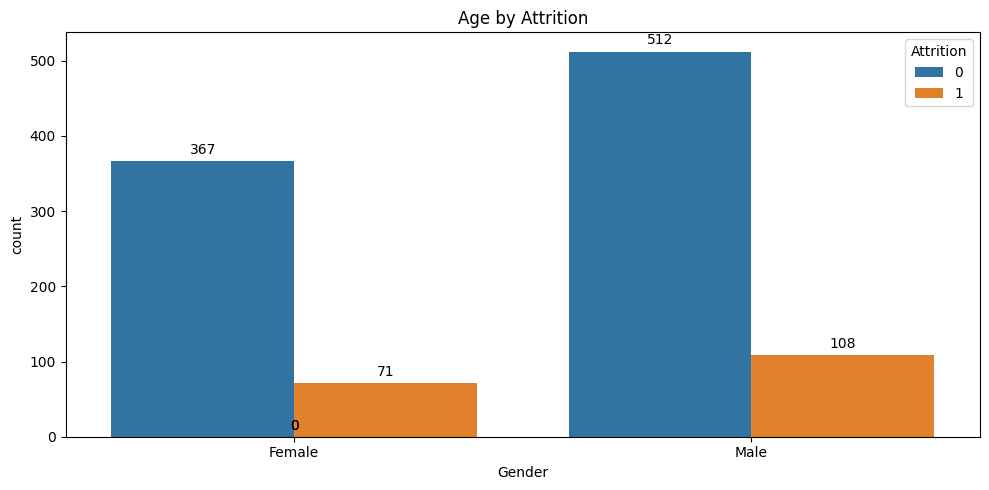

In [22]:
plt.figure(figsize=(10, 5))
ax = sns.countplot(x='Gender', hue='Attrition', data=employee_df)
plt.title('Age by Attrition')

# Menambahkan angka di atas setiap batang
for p in ax.patches:
    height = p.get_height()
    ax.annotate(str(int(p.get_height())), (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 8), textcoords='offset points')

plt.tight_layout()
plt.show()

### Department by Attrition

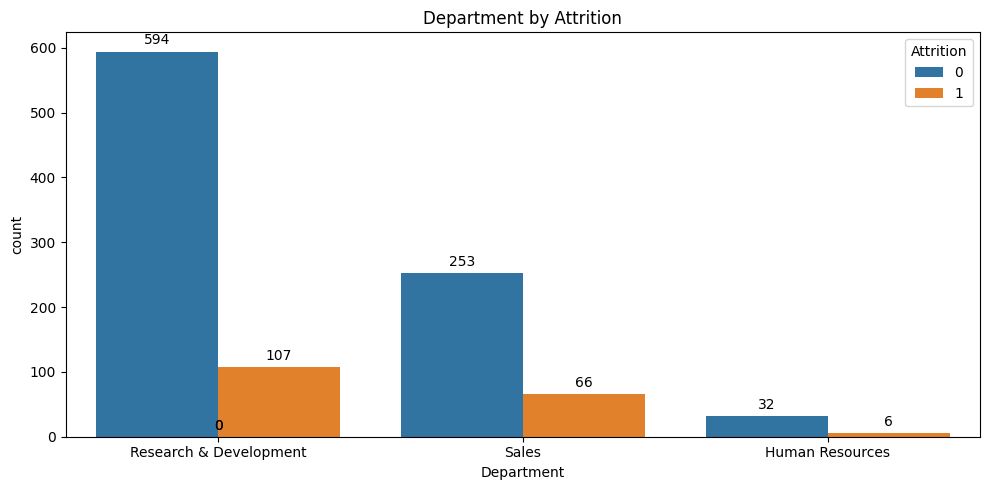

In [23]:
plt.figure(figsize=(10, 5))
ax = sns.countplot(x='Department', hue='Attrition', data=employee_df)
plt.title('Department by Attrition')

# Menambahkan angka di atas setiap batang
for p in ax.patches:
    height = p.get_height()
    ax.annotate(str(int(p.get_height())), (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 8), textcoords='offset points')

plt.tight_layout()
plt.show()

### Jobrole by Attrition

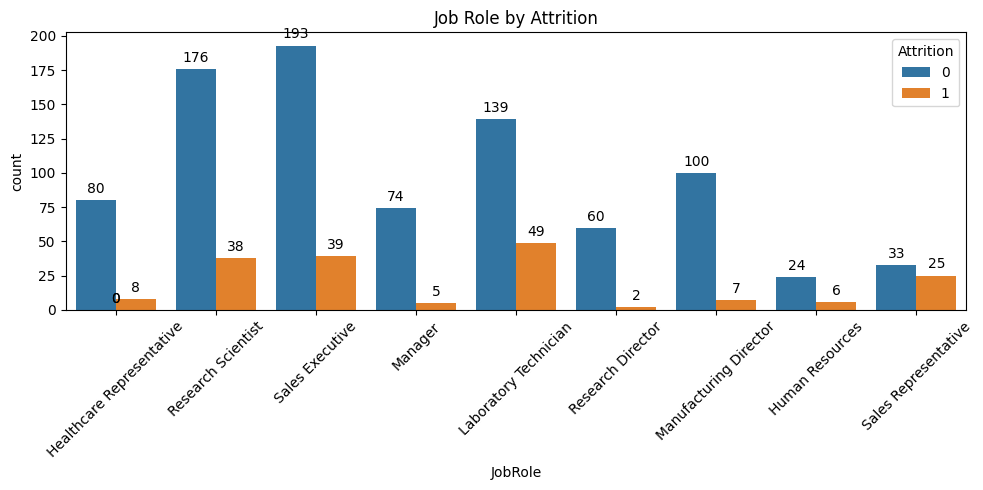

In [24]:
plt.figure(figsize=(10, 5))
ax = sns.countplot(x='JobRole', hue='Attrition', data=employee_df)
plt.title('Job Role by Attrition')

# Menambahkan angka di atas setiap batang
for p in ax.patches:
    height = p.get_height()
    ax.annotate(str(int(p.get_height())), (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 8), textcoords='offset points')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Education Field by Attrition

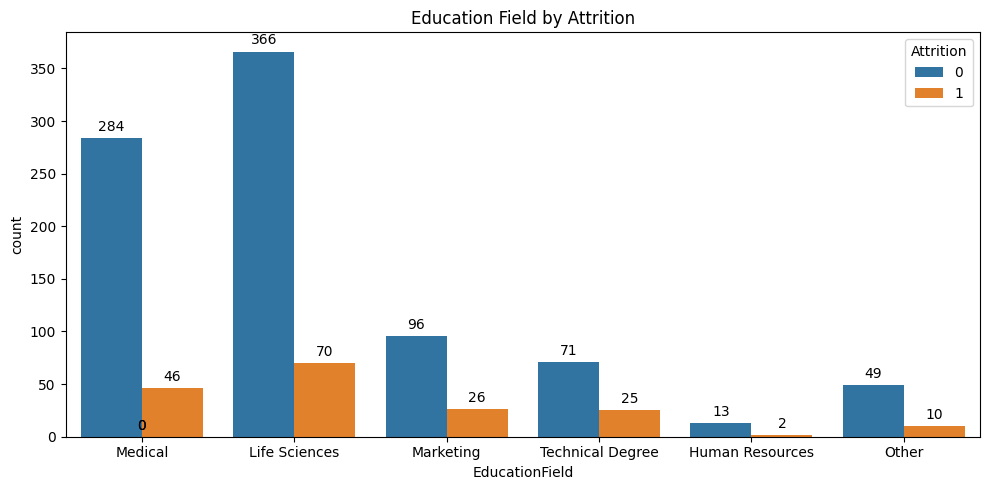

In [25]:
plt.figure(figsize=(10, 5))
ax = sns.countplot(x='EducationField', hue='Attrition', data=employee_df)
plt.title('Education Field by Attrition')

# Menambahkan angka di atas setiap batang
for p in ax.patches:
    height = p.get_height()
    ax.annotate(str(int(p.get_height())), (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 8), textcoords='offset points')

plt.tight_layout()
plt.show()

## Data Preparation / Preprocessing

###Labelling Data

In [26]:
employee_df['Department'] = preprocessing.LabelEncoder().fit_transform(employee_df['Department'])
employee_df['EducationField'] = preprocessing.LabelEncoder().fit_transform(employee_df['EducationField'])
employee_df['Gender'] = preprocessing.LabelEncoder().fit_transform(employee_df['Gender'])
employee_df['JobRole'] = preprocessing.LabelEncoder().fit_transform(employee_df['JobRole'])
employee_df['MaritalStatus'] = preprocessing.LabelEncoder().fit_transform(employee_df['MaritalStatus'])
employee_df['Over18'] = preprocessing.LabelEncoder().fit_transform(employee_df['Over18'])

### Imbalance Data

In [27]:
from imblearn.over_sampling import SMOTE

X = employee_df.drop(['Attrition', 'BusinessTravel', 'Education', 'OverTime'], axis=1)
y = employee_df['Attrition']

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

employee_df_resampled = pd.DataFrame(X_resampled, columns=X.columns)
employee_df_resampled['Attrition'] = y_resampled

### Standardization

In [28]:
Scaler = StandardScaler()
X = Scaler.fit_transform(X_resampled)
y = employee_df_resampled['Attrition']

### Splitting Data

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [30]:
print(X.shape)
print(X_train.shape)
print(X_test.shape)

(1758, 31)
(1406, 31)
(352, 31)


## Modeling

### Logistic Classifier

In [31]:
# Inisialisasi model klasifikasi Logistic Regression
logistic_model = LogisticRegression()

# Definisikan grid hiperparameter untuk Logistic Regression
logistic_param_grid = {
    'C': [0.1, 1, 10, 100],
    'max_iter': [100, 150, 200, 300],
    'multi_class': ['auto'],
    'solver': ['lbfgs', 'liblinear', 'newton-cg', 'sag', 'saga']
}

# Inisialisasi GridSearchCV untuk Logistic Regression
logistic_grid_search = GridSearchCV(
    estimator=logistic_model,
    param_grid=logistic_param_grid,
    scoring='accuracy',
    cv=5,
    n_jobs=-1
)

# Melatih model menggunakan GridSearchCV
logistic_model_best = logistic_grid_search.fit(X_train, y_train)

# Prediksi terhadap data uji
y_predicted_logistic = logistic_model_best.predict(X_test)

# Menampilkan parameter terbaik hasil pencarian
print("Best parameters:", logistic_model_best.best_params_)

# Menghitung dan menampilkan akurasi data uji
logistic_test_accuracy = accuracy_score(y_test, y_predicted_logistic)
print("LR Accuracy Score:", logistic_test_accuracy)

Best parameters: {'C': 0.1, 'max_iter': 100, 'multi_class': 'auto', 'solver': 'lbfgs'}
LR Accuracy Score: 0.8465909090909091


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


### K-Nearest Neighbor

In [32]:
# Inisialisasi model K-Nearest Neighbors Classifier
knn_model = KNeighborsClassifier()

# Definisikan grid hiperparameter untuk KNN
knn_param_grid = {
    'n_neighbors': [3, 5, 7],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# Inisialisasi GridSearchCV untuk KNN
knn_grid_search = GridSearchCV(
    estimator=knn_model,
    param_grid=knn_param_grid,
    cv=5,
    scoring='accuracy'
)

# Melatih model menggunakan GridSearchCV
knn_model_best = knn_grid_search.fit(X_train, y_train)

# Prediksi terhadap data uji
y_predicted_knn = knn_model_best.predict(X_test)

# Menampilkan parameter terbaik hasil pencarian
print("Best parameters:", knn_model_best.best_params_)

# Menghitung dan menampilkan akurasi data uji
knn_test_accuracy = accuracy_score(y_test, y_predicted_knn)
print("KNN Accuracy Score:", knn_test_accuracy)

Best parameters: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}
KNN Accuracy Score: 0.8835227272727273


### SVM Classifier

In [33]:
# Inisialisasi model Support Vector Machine Classifier
svm_model = SVC(probability=True)

# Definisikan grid hiperparameter untuk SVM
svm_param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf'],
    'gamma': [0.1, 1, 'scale']
}

# Inisialisasi GridSearchCV untuk SVM
svm_grid_search = GridSearchCV(
    estimator=svm_model,
    param_grid=svm_param_grid,
    cv=5,
    scoring='accuracy'
)

# Melatih model menggunakan GridSearchCV
svm_model_best = svm_grid_search.fit(X_train, y_train)

# Prediksi terhadap data uji
y_predicted_svm = svm_model_best.predict(X_test)

# Menampilkan parameter terbaik hasil pencarian
print("Best parameters:", svm_model_best.best_params_)

# Menghitung dan menampilkan akurasi data uji
svm_test_accuracy = accuracy_score(y_test, y_predicted_svm)
print("SVM Accuracy Score:", svm_test_accuracy)

Best parameters: {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}
SVM Accuracy Score: 0.9289772727272727


### Decision Tree Classifier

In [34]:
# Inisialisasi model Decision Tree Classifier
decision_tree_model = DecisionTreeClassifier()

# Definisikan grid hiperparameter untuk Decision Tree
decision_tree_param_grid = {
    'min_samples_leaf': [1, 10, 100],
    'max_depth': [1, 10, 20, 30],
    'criterion': ['gini', 'entropy']
}

# Inisialisasi GridSearchCV untuk Decision Tree
decision_tree_grid_search = GridSearchCV(
    estimator=decision_tree_model,
    param_grid=decision_tree_param_grid,
    cv=5,
    n_jobs=-1,
    scoring='accuracy'
)

# Melatih model menggunakan GridSearchCV
decision_tree_model_best = decision_tree_grid_search.fit(X_train, y_train)

# Prediksi terhadap data uji
y_predicted_dt = decision_tree_model_best.predict(X_test)

# Menampilkan parameter terbaik hasil pencarian
print("Best parameters:", decision_tree_model_best.best_params_)

# Menghitung dan menampilkan akurasi data uji
decision_tree_test_accuracy = accuracy_score(y_test, y_predicted_dt)
print("DT Accuracy Score:", decision_tree_test_accuracy)

Best parameters: {'criterion': 'gini', 'max_depth': 30, 'min_samples_leaf': 1}
DT Accuracy Score: 0.8125


### Random Forest Classifier

In [35]:
# Inisialisasi model Random Forest Classifier
random_forest_model = RandomForestClassifier()

# Definisikan grid hiperparameter untuk Random Forest
random_forest_param_grid = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [3, 5, 7, 9],
    'criterion': ['gini', 'entropy']
}

# Inisialisasi GridSearchCV untuk Random Forest
random_forest_grid_search = GridSearchCV(
    estimator=random_forest_model,
    param_grid=random_forest_param_grid,
    cv=5,
    n_jobs=-1,
    scoring='accuracy'
)

# Melatih model menggunakan GridSearchCV
random_forest_model_best = random_forest_grid_search.fit(X_train, y_train)

# Prediksi terhadap data uji
y_predicted_rf = random_forest_model_best.predict(X_test)

# Menampilkan parameter terbaik hasil pencarian
print("Best parameters:", random_forest_model_best.best_params_)

# Menghitung dan menampilkan akurasi data uji
random_forest_test_accuracy = accuracy_score(y_test, y_predicted_rf)
print("RF Accuracy Score:", random_forest_test_accuracy)

Best parameters: {'criterion': 'gini', 'max_depth': 9, 'n_estimators': 400}
RF Accuracy Score: 0.9090909090909091


## Evaluation

### Logistic Classifier

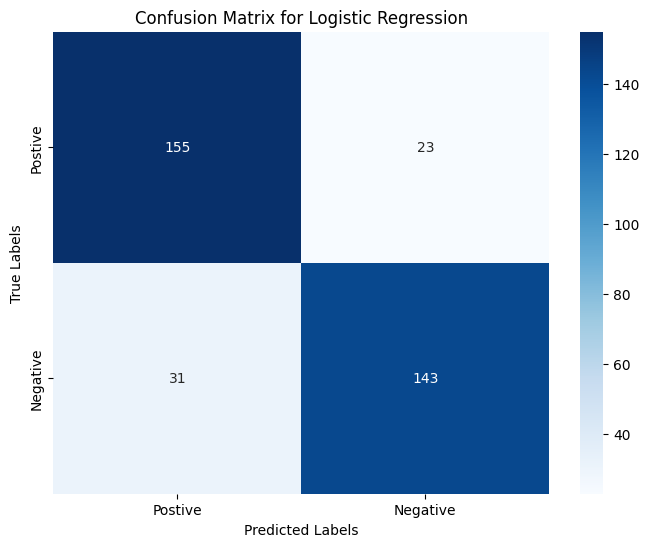

              precision    recall  f1-score   support

           0       0.83      0.87      0.85       178
           1       0.86      0.82      0.84       174

    accuracy                           0.85       352
   macro avg       0.85      0.85      0.85       352
weighted avg       0.85      0.85      0.85       352



In [36]:
# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_predicted_logistic)

# Plot the confusion matrix using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Postive', 'Negative'],
            yticklabels=['Postive', 'Negative'])
plt.title("Confusion Matrix for Logistic Regression")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

# Print classification report for more detailed evaluation
print(classification_report(y_test, y_predicted_logistic))


### K-Nearest Neighbor

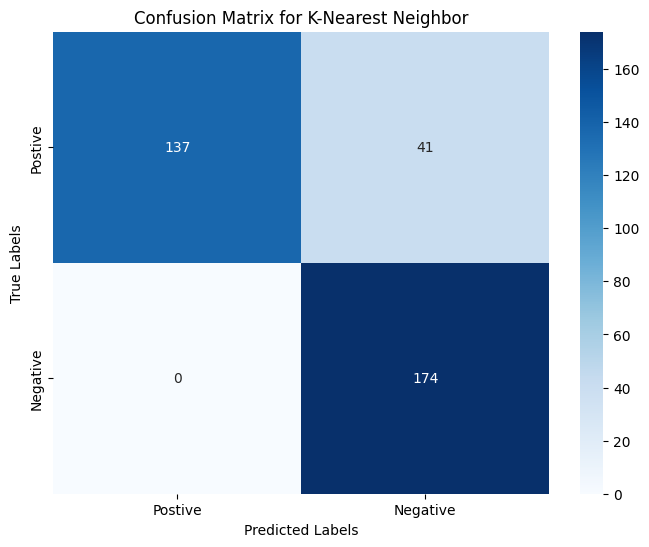

              precision    recall  f1-score   support

           0       1.00      0.77      0.87       178
           1       0.81      1.00      0.89       174

    accuracy                           0.88       352
   macro avg       0.90      0.88      0.88       352
weighted avg       0.91      0.88      0.88       352



In [37]:
# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_predicted_knn)

# Plot the confusion matrix using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Postive', 'Negative'],
            yticklabels=['Postive', 'Negative'])
plt.title("Confusion Matrix for K-Nearest Neighbor")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

# Print classification report for more detailed evaluation
print(classification_report(y_test, y_predicted_knn))


### SVM Classifier

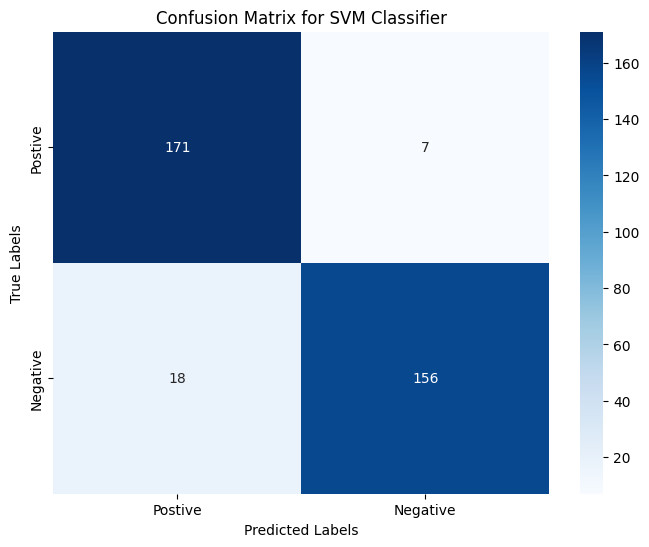

              precision    recall  f1-score   support

           0       0.90      0.96      0.93       178
           1       0.96      0.90      0.93       174

    accuracy                           0.93       352
   macro avg       0.93      0.93      0.93       352
weighted avg       0.93      0.93      0.93       352



In [38]:
# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_predicted_svm)

# Plot the confusion matrix using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Postive', 'Negative'],
            yticklabels=['Postive', 'Negative'])
plt.title("Confusion Matrix for SVM Classifier")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

# Print classification report for more detailed evaluation
print(classification_report(y_test, y_predicted_svm))


### Decision Tree Classifier

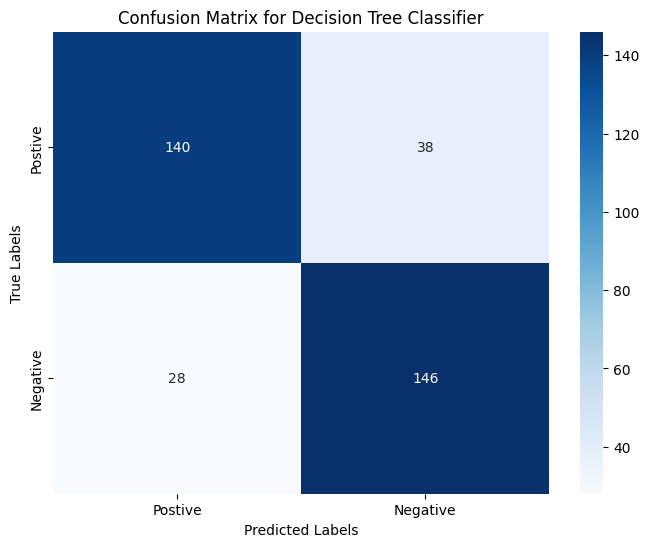

              precision    recall  f1-score   support

           0       0.83      0.79      0.81       178
           1       0.79      0.84      0.82       174

    accuracy                           0.81       352
   macro avg       0.81      0.81      0.81       352
weighted avg       0.81      0.81      0.81       352



In [39]:
# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_predicted_dt)

# Plot the confusion matrix using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Postive', 'Negative'],
            yticklabels=['Postive', 'Negative'])
plt.title("Confusion Matrix for Decision Tree Classifier")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

# Print classification report for more detailed evaluation
print(classification_report(y_test, y_predicted_dt))


### Random Forest Classifier

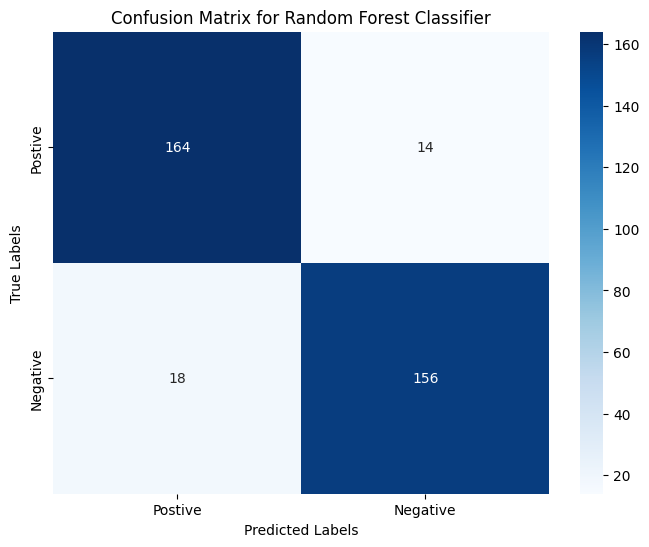

              precision    recall  f1-score   support

           0       0.90      0.92      0.91       178
           1       0.92      0.90      0.91       174

    accuracy                           0.91       352
   macro avg       0.91      0.91      0.91       352
weighted avg       0.91      0.91      0.91       352



In [40]:
# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_predicted_rf)

# Plot the confusion matrix using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Postive', 'Negative'],
            yticklabels=['Postive', 'Negative'])
plt.title("Confusion Matrix for Random Forest Classifier")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

# Print classification report for more detailed evaluation
print(classification_report(y_test, y_predicted_rf))


## Deployment

In [41]:
joblib.dump(random_forest_model_best, 'random_forest_model.pkl')

['random_forest_model.pkl']

In [51]:
import session_info

In [49]:
session_info.show(write_req_file=True, req_file_name='requirements.txt')

In [50]:
!cat requirements.txt

imblearn==0.13.0
joblib==1.4.2
matplotlib==3.10.0
numpy==2.0.2
pandas==2.2.2
seaborn==0.13.2
session_info==v1.0.1
sklearn==1.6.1
IPython==8.12.3
jupyter_client==6.1.12
jupyter_core==5.7.2
notebook==6.5.7
